In [3]:
import json
import matplotlib.pyplot as plt
import pprint
import math
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from collections import defaultdict
import os
from matplotlib.ticker import MultipleLocator
import matplotlib.patheffects as path_effects

In [45]:
with open("data/items.json", "r") as f:
    items = json.load(f)

with open("data/recipes.json", "r") as f:
    recipes = json.load(f)

name_to_recipe = {}
for recipe in recipes:
    for out in recipe["output"]:
        item_name = items[out["id"]]["name"]
        name_to_recipe[item_name] = recipe

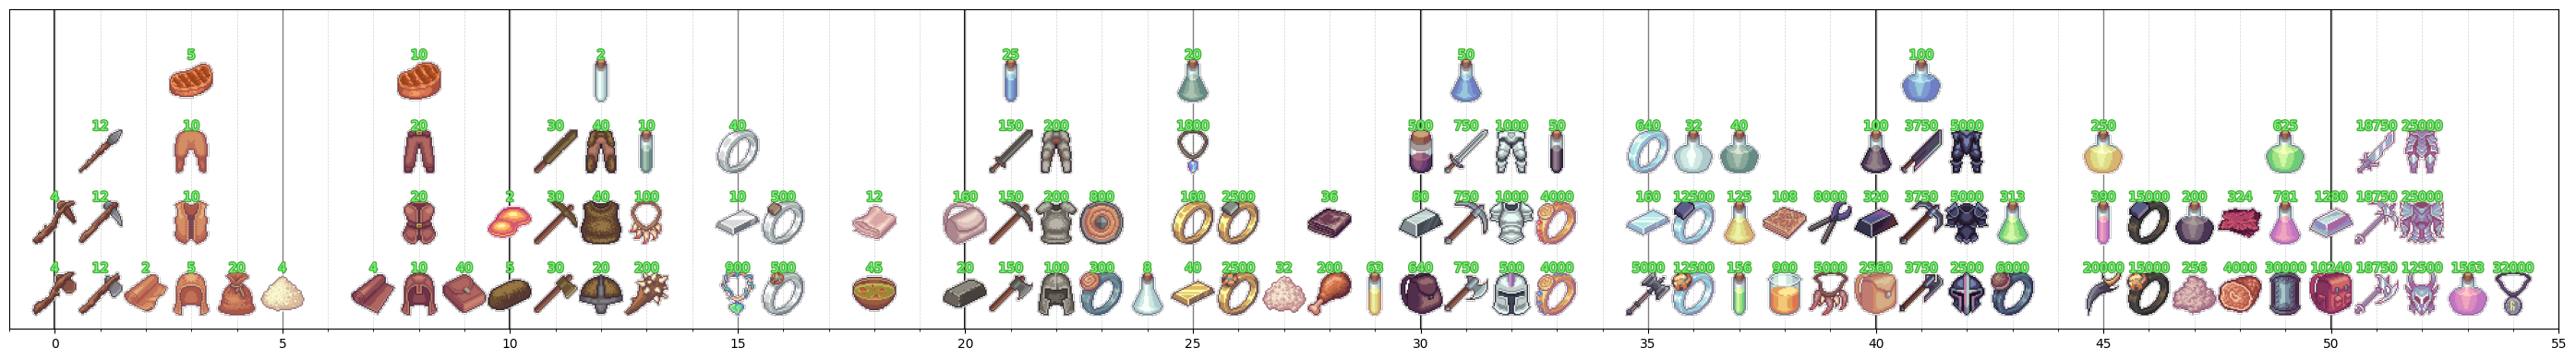

In [ ]:
show_actions = False



# Organize items by level
level_items = defaultdict(list)
item_metadata = {}  # Map item_id to (lvl, xp, actions)

for recipe in recipes:
    lvl = recipe["lvl"]
    xp = recipe["xp"]
    actions = recipe["actions"]
    for item in recipe["output"]:
        item_id = item["id"]
        level_items[lvl].append(item_id)
        item_metadata[item_id] = (xp, actions)

# Sort levels
levels = sorted(level_items.keys())

# Setup plot
fig, ax = plt.subplots(figsize=(28, 4))  # Reduced vertical height

max_stack_height = 0
for lvl in levels:
    lvl_items = level_items[lvl]
    for i, item_id in enumerate(lvl_items):
        image_path = f"../images/items/{item_id}.png"
        if os.path.exists(image_path):
            try:
                img = plt.imread(image_path)
                imagebox = OffsetImage(img, zoom=1)
                ab = AnnotationBbox(imagebox, (lvl, i), frameon=False)
                ax.add_artist(ab)

                # Get metadata and draw 3 lines of text above the icon
                xp, actions = item_metadata.get(item_id, ("?", "?"))
                text_y = i + 0.3  # slightly above icon
                ax.text(lvl, text_y , f"{xp}", fontsize=10, ha='center', color="#7aff88", path_effects=[path_effects.Stroke(linewidth=2, foreground="#4ab038"), path_effects.Normal()])
                if show_actions:
                    ax.text(lvl, text_y + 0.2, f"{actions}", fontsize=10, ha='center', color="#82EAFF", path_effects=[path_effects.Stroke(linewidth=2, foreground="#4d6cba"), path_effects.Normal()])
            except Exception as e:
                print(f"Failed to load {image_path}: {e}")
        else:
            print(f"Missing icon: {image_path}")
    max_stack_height = max(max_stack_height, len(lvl_items))

# Axis styling
ax.set_xlim(min(levels) - 1, max(levels) + 1)
ax.set_ylim(-0.5, max_stack_height)  # leave room for text

# Gridlines
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(which='major', axis='x', color='gray', linestyle='-', linewidth=1)
ax.grid(which='minor', axis='x', color='lightgray', linestyle='--', linewidth=0.5)

for lvl in range(min(levels), max(levels) + 1):
    if lvl % 10 == 0:
        ax.axvline(x=lvl, color='black', linestyle='-', linewidth=1.5, zorder=0)

# Ticks: show both major and minor with different sizes
ax.tick_params(axis='x', which='major', labelsize=10)
ax.tick_params(axis='x', which='minor', labelsize=8, labelbottom=True)

# Hide vertical axis
ax.yaxis.set_visible(False)

plt.tight_layout()
plt.show()

In [40]:
xp_req = 200
print(xp_req)
for i in range(4):
    xp_req *= 4.5
    print(xp_req)


200
900.0
4050.0
18225.0
82012.5


In [43]:
# --- edit here ---
lookup = "Cooked Mammoth Shank"
new_xp = 4000
# -----------------

recipe = name_to_recipe.get(lookup)
if recipe is None:
    print(f"No recipe found for: {lookup}")
else:
    if new_xp is not None:
        print(f"{lookup}: {recipe['xp']} xp  ->  {new_xp} xp")
        recipe["xp"] = new_xp
    else:
        print(f"{lookup}: lvl {recipe['lvl']}, {recipe['xp']} xp, {recipe['actions']} actions")


Cooked Mammoth Shank: 2304 xp  ->  4000 xp


In [44]:
with open("data/recipes.json", "w") as f:
    json.dump(recipes, f)
